<a href="https://colab.research.google.com/github/yoghan007/dlv_exp/blob/main/Implementation_of_Deep_Generative_Model_for_Image_Editing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - kl_loss: 1.1479 - loss: 18.2184 - reconstruction_loss: 17.0706
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - kl_loss: 1.0650 - loss: 16.2090 - reconstruction_loss: 15.1441
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - kl_loss: 1.2387 - loss: 16.1017 - reconstruction_loss: 14.8629
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - kl_loss: 1.3555 - loss: 16.0428 - reconstruction_loss: 14.6874
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - kl_loss: 1.4054 - loss: 15.9952 - reconstruction_loss: 14.5896
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - kl_loss: 1.4536 - loss: 15.9645 - reconstruction_loss: 14.5107
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - kl_loss: 1.4837 - loss: 15.9373 - reconstruction_loss: 14.4537
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - kl_loss: 1.5282 - loss: 15.9157 - reconstruction_loss: 14.3874
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - kl_loss

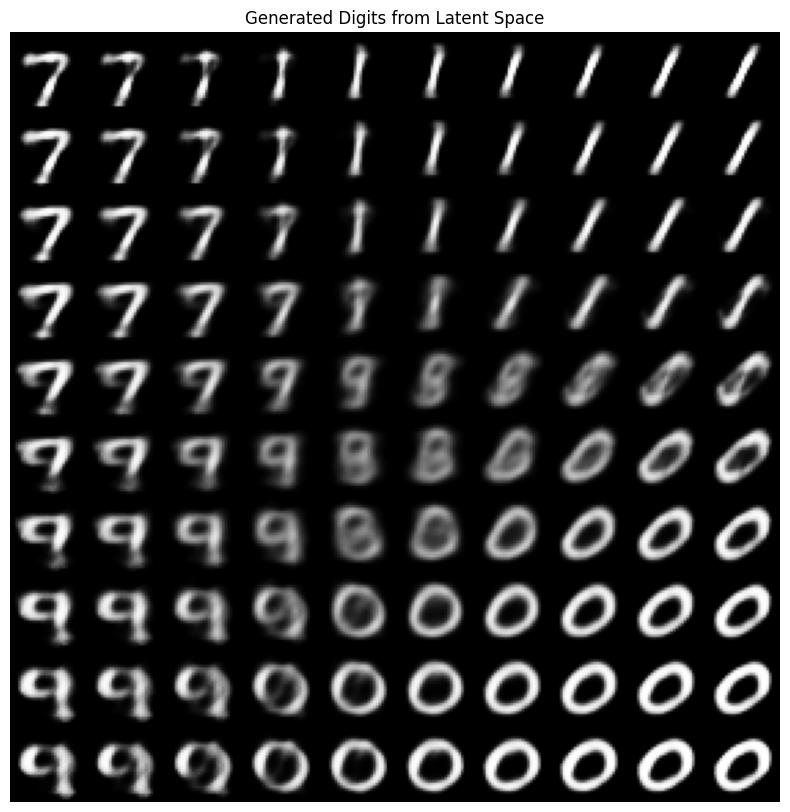

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras import backend as K
import tensorflow as tf

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))

latent_dim = 2

# Sampling function (remains the same)
def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

# Define the Encoder Model
encoder_inputs = layers.Input(shape=(28, 28, 1), name="encoder_input")
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation='relu')(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = layers.Lambda(sampling, output_shape=(latent_dim,), name="z")([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Define the Decoder Model
decoder_input = layers.Input(shape=(latent_dim,), name="decoder_input")
x = layers.Dense(128, activation='relu')(decoder_input)
x = layers.Dense(784, activation='sigmoid')(x)
decoded = layers.Reshape((28, 28, 1))(x)
decoder = models.Model(decoder_input, decoded, name="decoder")

# Custom VAE Model class
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")
        # Instantiate the BinaryCrossentropy loss with no reduction
        self.bce_loss = tf.keras.losses.BinaryCrossentropy(reduction=tf.keras.losses.Reduction.NONE)

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]  # Assuming x_train, x_train for fit

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss (binary cross-entropy per pixel, then summed per image)
            # Use the instantiated bce_loss object
            reconstruction_loss = self.bce_loss(
                layers.Flatten()(data), layers.Flatten()(reconstruction)
            )
            reconstruction_loss = tf.keras.ops.sum(reconstruction_loss, axis=-1)

            # KL divergence loss (per image)
            kl_loss = -0.5 * tf.keras.ops.sum(
                1 + z_log_var - tf.keras.ops.square(z_mean) - tf.keras.ops.exp(z_log_var),
                axis=-1
            )
            # Total loss for the batch, averaged over samples
            total_loss = tf.keras.ops.mean(reconstruction_loss + kl_loss)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    # The call method is used for inference/prediction
    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

# Instantiate and compile the custom VAE model
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam') # Loss is handled in train_step
vae.fit(x_train, x_train, epochs=10, batch_size=64)

def plot_latent_space(decoder, n=10):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    grid_x = np.linspace(-4, 4, n)
    grid_y = np.linspace(-4, 4, n)

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap='gray')
    plt.axis('off')
    plt.title("Generated Digits from Latent Space")
    plt.show()

plot_latent_space(decoder)